In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import math

In [41]:
# S3 input paths
##S3_BUCKET = "s3://ads508-housing-data-faye"

S3_BUCKET = "sagemaker-studio-mru71pwhjb"

ZHVI_PATH = f"s3://{S3_BUCKET}/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
INVENTORY_PATH = f"s3://{S3_BUCKET}/Metro_invt_fs_uc_sfrcondo_sm_month.csv"
MARKET_TEMP_PATH = f"s3://{S3_BUCKET}/Metro_market_temp_index_uc_sfrcondo_month.csv"
SALE_PRICE_PATH = f"s3://{S3_BUCKET}/Metro_median_sale_price_uc_sfrcondo_sm_week.csv"

# S3 output paths
TRAIN_OUT = f"s3://{S3_BUCKET}/prepared/train.csv"
TEST_OUT = f"s3://{S3_BUCKET}/prepared/test.csv"
FULL_OUT = f"s3://{S3_BUCKET}/prepared/full_prepared_dataset.csv"

In [42]:
zhvi = pd.read_csv(ZHVI_PATH)
inventory = pd.read_csv(INVENTORY_PATH)
market_temp = pd.read_csv(MARKET_TEMP_PATH)
sale_price = pd.read_csv(SALE_PRICE_PATH)

print("ZHVI:", zhvi.shape)
print("Inventory:", inventory.shape)
print("Market Temp:", market_temp.shape)
print("Sale Price:", sale_price.shape)

ZHVI: (895, 318)
Inventory: (928, 100)
Market Temp: (928, 102)
Sale Price: (165, 939)


In [43]:
def basic_clean(df):
    # Remove exact duplicate rows
    df = df.drop_duplicates().copy()
    
    # Keep only metro areas if available
    if "RegionType" in df.columns:
        df = df[df["RegionType"] == "msa"].copy()
    
    # Drop obvious aggregate row if still present
    if "RegionName" in df.columns:
        df = df[df["RegionName"] != "United States"].copy()
    
    return df

zhvi = basic_clean(zhvi)
inventory = basic_clean(inventory)
market_temp = basic_clean(market_temp)
sale_price = basic_clean(sale_price)

print("ZHVI cleaned:", zhvi.shape)
print("Inventory cleaned:", inventory.shape)
print("Market Temp cleaned:", market_temp.shape)
print("Sale Price cleaned:", sale_price.shape)

ZHVI cleaned: (894, 318)
Inventory cleaned: (927, 100)
Market Temp cleaned: (927, 102)
Sale Price cleaned: (164, 939)


In [44]:
ID_COLS = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]

def wide_to_long(df, value_name):
    date_cols = [c for c in df.columns if c not in ID_COLS]
    long_df = df.melt(
        id_vars=ID_COLS,
        value_vars=date_cols,
        var_name="Date",
        value_name=value_name
    )
    long_df["Date"] = pd.to_datetime(long_df["Date"], errors="coerce")
    long_df = long_df.dropna(subset=["Date"])
    return long_df

zhvi_long = wide_to_long(zhvi, "ZHVI")
inventory_long = wide_to_long(inventory, "Inventory")
market_temp_long = wide_to_long(market_temp, "MarketTemp")
sale_price_long = wide_to_long(sale_price, "MedianSalePrice")

print("ZHVI long:", zhvi_long.shape)
print("Inventory long:", inventory_long.shape)
print("Market Temp long:", market_temp_long.shape)
print("Sale Price long:", sale_price_long.shape)

ZHVI long: (279822, 7)
Inventory long: (88065, 7)
Market Temp long: (89919, 7)
Sale Price long: (153176, 7)


In [45]:
sale_price_long["Date"] = sale_price_long["Date"].dt.to_period("M").dt.to_timestamp("M")
sale_price_monthly = (
    sale_price_long
    .groupby(["RegionID", "RegionName", "StateName", "Date"], as_index=False)["MedianSalePrice"]
    .mean()
)

sale_price_monthly.head()

,RegionID,RegionName,StateName,Date,MedianSalePrice
0,394299,"Abilene, TX",TX,2008-02-29,NaN
1,394299,"Abilene, TX",TX,2008-03-31,NaN
2,394299,"Abilene, TX",TX,2008-04-30,NaN
3,394299,"Abilene, TX",TX,2008-05-31,NaN
4,394299,"Abilene, TX",TX,2008-06-30,NaN


In [46]:
merge_keys = ["RegionID", "RegionName", "StateName", "Date"]

df = zhvi_long.merge(
    inventory_long[merge_keys + ["Inventory"]],
    on=merge_keys,
    how="left"
).merge(
    market_temp_long[merge_keys + ["MarketTemp"]],
    on=merge_keys,
    how="left"
).merge(
    sale_price_monthly,
    on=merge_keys,
    how="left"
)

print(df.shape)
df.head()

(279822, 10)


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,Inventory,MarketTemp,MedianSalePrice
0,394913,1,"New York, NY",msa,NY,2000-01-31,216213.074441,NaN,NaN,NaN
1,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,219357.633964,NaN,NaN,NaN
2,394463,3,"Chicago, IL",msa,IL,2000-01-31,149975.869412,NaN,NaN,NaN
3,394514,4,"Dallas, TX",msa,TX,2000-01-31,126453.868825,NaN,NaN,NaN
4,394692,5,"Houston, TX",msa,TX,2000-01-31,122700.097397,NaN,NaN,NaN


In [47]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)

MedianSalePrice    248440
Inventory          195039
MarketTemp         194337
ZHVI                49266
dtype: int64

In [48]:
# Remove rows without target
df = df.dropna(subset=["ZHVI"]).copy()

# Sort for time-based operations
df = df.sort_values(["RegionName", "Date"]).copy()

# Forward fill numeric market indicators within each metro
for col in ["Inventory", "MarketTemp", "MedianSalePrice"]:
    df[col] = df.groupby("RegionName")[col].transform(lambda s: s.ffill())

# Optional backfill remaining early missing values within metro
for col in ["Inventory", "MarketTemp", "MedianSalePrice"]:
    df[col] = df.groupby("RegionName")[col].transform(lambda s: s.bfill())

# Drop rows still missing important predictors
df = df.dropna(subset=["Inventory", "MarketTemp"]).copy()

print(df.shape)
df.head()

(230556, 10)


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,Inventory,MarketTemp,MedianSalePrice
98103,394297,677,"Aberdeen, SD",msa,SD,2009-02-28,125066.417884,189.0,38.0,NaN
98997,394297,677,"Aberdeen, SD",msa,SD,2009-03-31,125079.142534,189.0,38.0,NaN
99891,394297,677,"Aberdeen, SD",msa,SD,2009-04-30,124888.758875,189.0,38.0,NaN
100785,394297,677,"Aberdeen, SD",msa,SD,2009-05-31,124780.972274,189.0,38.0,NaN
101679,394297,677,"Aberdeen, SD",msa,SD,2009-06-30,124593.031335,189.0,38.0,NaN


In [49]:
# Time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Lag features by metro
df["ZHVI_Lag1"] = df.groupby("RegionName")["ZHVI"].shift(1)
df["Inventory_Lag1"] = df.groupby("RegionName")["Inventory"].shift(1)
df["MarketTemp_Lag1"] = df.groupby("RegionName")["MarketTemp"].shift(1)

# Month-over-month percent changes
df["ZHVI_PctChange"] = df.groupby("RegionName")["ZHVI"].pct_change()
df["Inventory_PctChange"] = df.groupby("RegionName")["Inventory"].pct_change()

# Optional log target if you want to reduce skew
df["Log_ZHVI"] = np.log1p(df["ZHVI"])

df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,Inventory,MarketTemp,MedianSalePrice,Year,Month,ZHVI_Lag1,Inventory_Lag1,MarketTemp_Lag1,ZHVI_PctChange,Inventory_PctChange,Log_ZHVI
98103,394297,677,"Aberdeen, SD",msa,SD,2009-02-28,125066.417884,189.0,38.0,NaN,2009,2,NaN,NaN,NaN,NaN,NaN,11.736608
98997,394297,677,"Aberdeen, SD",msa,SD,2009-03-31,125079.142534,189.0,38.0,NaN,2009,3,125066.417884,189.0,38.0,0.000102,0.0,11.736710
99891,394297,677,"Aberdeen, SD",msa,SD,2009-04-30,124888.758875,189.0,38.0,NaN,2009,4,125079.142534,189.0,38.0,-0.001522,0.0,11.735187
100785,394297,677,"Aberdeen, SD",msa,SD,2009-05-31,124780.972274,189.0,38.0,NaN,2009,5,124888.758875,189.0,38.0,-0.000863,0.0,11.734323
101679,394297,677,"Aberdeen, SD",msa,SD,2009-06-30,124593.031335,189.0,38.0,NaN,2009,6,124780.972274,189.0,38.0,-0.001506,0.0,11.732816


In [50]:
df = df.dropna(subset=["ZHVI_Lag1", "Inventory_Lag1", "MarketTemp_Lag1"]).copy()
print(df.shape)

(229662, 18)


In [51]:
feature_cols = [
    "StateName",
    "Year",
    "Month",
    "Inventory",
    "MarketTemp",
    "MedianSalePrice",
    "ZHVI_Lag1",
    "Inventory_Lag1",
    "MarketTemp_Lag1",
    "ZHVI_PctChange",
    "Inventory_PctChange"
]

target_col = "ZHVI"       # primary target
# target_col = "Log_ZHVI" # optional alternative if you want log target

model_df = df[["RegionID", "RegionName", "Date"] + feature_cols + [target_col]].copy()
model_df.head()

,RegionID,RegionName,Date,StateName,Year,Month,Inventory,MarketTemp,MedianSalePrice,ZHVI_Lag1,Inventory_Lag1,MarketTemp_Lag1,ZHVI_PctChange,Inventory_PctChange,ZHVI
98997,394297,"Aberdeen, SD",2009-03-31,SD,2009,3,189.0,38.0,NaN,125066.417884,189.0,38.0,0.000102,0.0,125079.142534
99891,394297,"Aberdeen, SD",2009-04-30,SD,2009,4,189.0,38.0,NaN,125079.142534,189.0,38.0,-0.001522,0.0,124888.758875
100785,394297,"Aberdeen, SD",2009-05-31,SD,2009,5,189.0,38.0,NaN,124888.758875,189.0,38.0,-0.000863,0.0,124780.972274
101679,394297,"Aberdeen, SD",2009-06-30,SD,2009,6,189.0,38.0,NaN,124780.972274,189.0,38.0,-0.001506,0.0,124593.031335
102573,394297,"Aberdeen, SD",2009-07-31,SD,2009,7,189.0,38.0,NaN,124593.031335,189.0,38.0,-0.001066,0.0,124460.260750


In [52]:
model_df.isnull().sum().sort_values(ascending=False)

MedianSalePrice        181040
RegionName                  0
RegionID                    0
StateName                   0
Year                        0
Month                       0
Date                        0
Inventory                   0
MarketTemp                  0
ZHVI_Lag1                   0
Inventory_Lag1              0
MarketTemp_Lag1             0
ZHVI_PctChange              0
Inventory_PctChange         0
ZHVI                        0
dtype: int64

In [53]:
cutoff_date = model_df["Date"].quantile(0.80)
print("Cutoff date:", cutoff_date)

train_df = model_df[model_df["Date"] <= cutoff_date].copy()
test_df = model_df[model_df["Date"] > cutoff_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test date range:", test_df["Date"].min(), "to", test_df["Date"].max())

Cutoff date: 2021-10-31 00:00:00
Train shape: (184069, 15)
Test shape: (45593, 15)
Train date range: 2000-02-29 00:00:00 to 2021-10-31 00:00:00
Test date range: 2021-11-30 00:00:00 to 2026-01-31 00:00:00


In [54]:
train_df.to_csv(TRAIN_OUT, index=False)
test_df.to_csv(TEST_OUT, index=False)
model_df.to_csv(FULL_OUT, index=False)

print("Saved:")
print(TRAIN_OUT)
print(TEST_OUT)
print(FULL_OUT)

Saved:
s3://sagemaker-studio-mru71pwhjb/prepared/train.csv
s3://sagemaker-studio-mru71pwhjb/prepared/test.csv
s3://sagemaker-studio-mru71pwhjb/prepared/full_prepared_dataset.csv


In [55]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [59]:
numeric_features = [
    "Year", "Month", "Inventory", "MarketTemp", "MedianSalePrice",
    "ZHVI_Lag1", "Inventory_Lag1", "MarketTemp_Lag1",
    "ZHVI_PctChange", "Inventory_PctChange"
]

categorical_features = ["StateName"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

In [57]:
rmse = math.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 866.9741921423807
RMSE: 9406.508290230491
R2: 0.9969010769175993


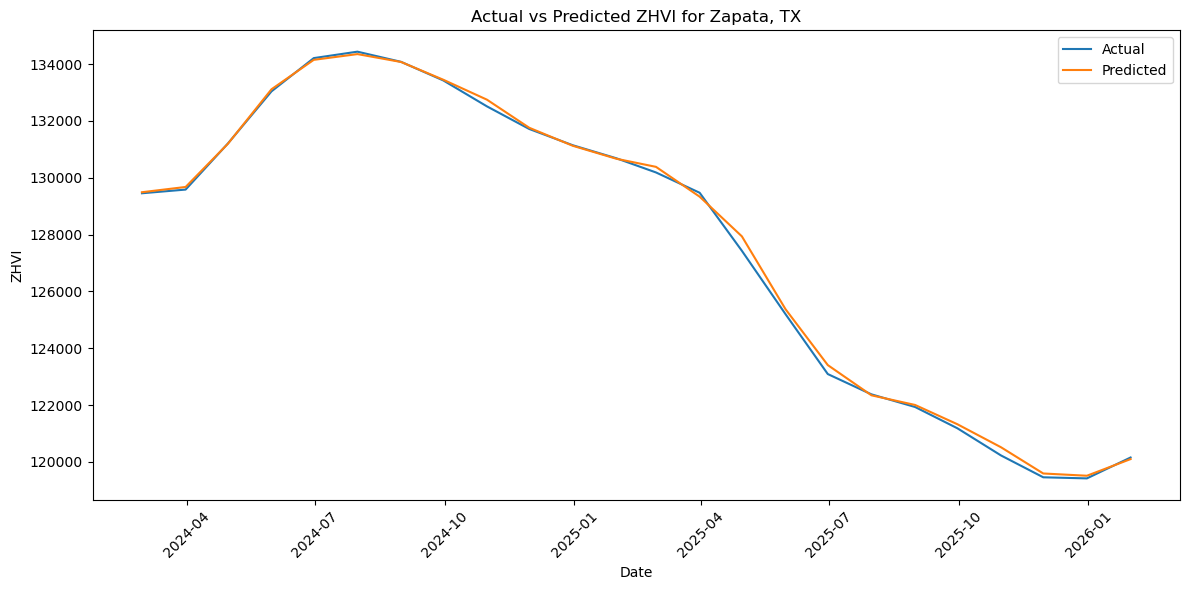

In [58]:
results = test_df[["Date", "RegionName"]].copy()
results["Actual"] = y_test.values
results["Predicted"] = preds

top_region = results["RegionName"].value_counts().index[0]
sample = results[results["RegionName"] == top_region].sort_values("Date").tail(24)

plt.figure(figsize=(12, 6))
plt.plot(sample["Date"], sample["Actual"], label="Actual")
plt.plot(sample["Date"], sample["Predicted"], label="Predicted")
plt.title(f"Actual vs Predicted ZHVI for {top_region}")
plt.xlabel("Date")
plt.ylabel("ZHVI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()